<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/260911_%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 토픽 모델링(Topic Modeling) - 20 뉴스그룹

*   **토픽 모델링**이란 **문서 집합에 숨어 있는 주제를 찾아내는 것**임. 많은 양의 문서가 있을 때 사람이 이 문서를 다 읽고 핵심 주제를 찾는 것은 매우 많은 시간이 소요됨. 이 경우에 머신러닝 기반의 토픽 모델링을 적용해 숨어 있는 중요 주제를 효과적으로 찾아낼 수 있음.
*   사람이 수행하는 토픽 모델링은 더 함축적인 의미로 문장을 요약하는 것에 반해, 머신러닝 기반의 토픽 모델은 **숨겨진 주제를 효과적으로 표현할 수 있는 중심 단어를 함축적으로 추출**함.

*   머신러닝 기반의 토픽 모델링에 자주 사용되는 기법은 **LSA(Latent Semantic Analysis)와 LDA(Latent Dirchlet Allocation)**임. (* 토픽 모델링에 사용되는 LDA(Latent Dirichlet Allocation)와 앞서 차원 축소의 LDA(Linear Discriminant Analysis)는 약어만 같을 뿐 서로 다른 알고리즘임.)
*   사이킷런은 LDA(Latent Dirichlet Allocation) 기반의 토픽 모델링을 **LatentDirchletAllocation 클래스**로 제공함.





In [1]:
# 20 뉴스그룹 데이터 세트를 이용해 토픽 모델링을 적용하는 예제

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

## 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교, 전자공학, 의학 8개 주제를 추출
cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x',
        'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']

## LDA 토픽 모델링을 위해 fetch_20newsgroups() API는 categories 파라미터를 위해 필요한 주제만 필터링해 추출하고, 추출한 텍스트를 Count 기반으로 벡터화 변환
news_df = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'), categories=cats, random_state=0)
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english', ngram_range=(1, 2))
feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


CountVectorizzer 객체 변수인 feat_vect 모두 7862개의 문서가 1000개의 피처로 구성된 행렬 데이터임.

In [2]:
# 피처 벡터화된 데이터 세트를 기반으로 LDA 토픽 모델링 수행

lda = LatentDirichletAllocation(n_components=8, random_state=0)    ## 토픽의 개수는 위의 뉴스그룸에서 추출한 주제와 동일한 8개로 지정
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)



*   **LatentDirichletAllocation.fit(데이터 세트)을 수행하면 LatentDirichletAllocation 객체는 components_ 속성값을 가지게 됨.** components_는 **개별 토픽별로 각 word 피처가 얼마나 많이 그 토픽에 할당됐는지에 대한 수치**를 가지고 있음. 높은 값일수록 해당 word 피처는 그 토픽의 중심 word가 됨.



In [3]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

components_는 array[8, 1000]으로 구성되어 있음. 8개의 토픽별로 1000개의 word 피처가 해당 토픽별로 연관도 값을 가지고 있음. 즉, components_array의 0번째 row, 10번째 col에 있는 값은 Topic #0에 대해서 피처 벡터화된 행렬에서 10번째 칼럼에 해당하는 피처가 Topic #0에 연관되는 수치 값을 가지고 있음.

In [4]:
# lda_model.components_ 값만으로는 각 토픽별 word 연관도를 보기가 어려우므로 display_topics() 함수를 만들어 각 토픽별로 연관도가 높은 순으로 Word를 나열

def display_topics(model, feature_names, no_top_words):
  for topic_index, topic in enumerate(model.components_):
    print('Topic #', topic_index)
    ## components_array에서 가장 값이 큰 순으로 정렬했을 때, 그 값의 array 인덱스를 반환
    topic_word_indexes = topic.argsort()[::-1]
    top_indexes=topic_word_indexes[:no_top_words]
    ## top_indexes 대상인 인덱스별로 feature_names에 해당하는 word feature 추출 후 join으로 concat
    feature_concat = ' '.join([feature_names[i] for i in top_indexes])
    print(feature_concat)

## CountVectorizer 객체 내의 전체 word의 명칭을 get_features_names()를 통해 추출
feature_names = count_vect.get_feature_names_out()
## 토픽별 가장 연관도가 높은 word를 15개만 추출
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


Topic #0의 경우 일부 불분명한 주제어들이 있지만 주로 의학에 관련된 주제어가 추출됨. Topic #1의 경우 명확하지 않고 일반적인 단어가 주를 이루고 있음. Topic #2는 컴퓨터 그래픽스 영역의 주제어가 다수 포함되어 있음. Topic #3은 명확하게 중동 영역의 주제어가 추출되었음. Topic #4는 이스라엘과 팔레스타인 간 분쟁에 관한 주제어들이 추출되었음. Topic #5는 일부 컴퓨터 그래픽스 영역의 주제어를 포함하고 있지만, 전반적으로 컴퓨터 관련 용어들을 가지고 있어 8개 토픽 중 하나로 매핑하기는 어려움. Topic #6은 명확하게 기독교 관련 주제어가 추출됨. 마지막으로 Topic #7은 윈도우 운영체제와 관련된 주제어가 추출됨. 모터사이클, 야구 주제의 경우 명확한 주제어가 추출되지 않았음.

## 문서 유사도
### 문서 유사도 측정 방법 - 코사인 유사도

*   문서와 문서 간 유사도 비교는 일반적으로 **코사인 유사도(Cosine Similarity)**를 사용함. 코사인 유사도는 **벡터와 벡터 간의 유사도를 비교할 때 벡터의 크기보다는 벡터의 상호 방향성이 얼마나 유사한지에 기반**함. 즉, 코사인 유사도는 **두 벡터 사이의 사잇각을 구해서 얼마나 유사한지 수치로 적용한 것**임.
### 두 벡터 사잇각
*   두 벡터 사잇각에 따라서 상호 관계는 유사하거나, 관련이 없거나 아예 반대 관계가 될 수 있음. 두 벡터 A와 B의 코사인 값은 A * B = ||A||||B||cosθ이며, 유사도(similarity) cosθ는 두 벡터의 내적을 총 벡터 크기의 합으로 나눈 것임. 즉, 내적 결과를 총 벡터 크기로 정규화(L2 Norm)한 것임.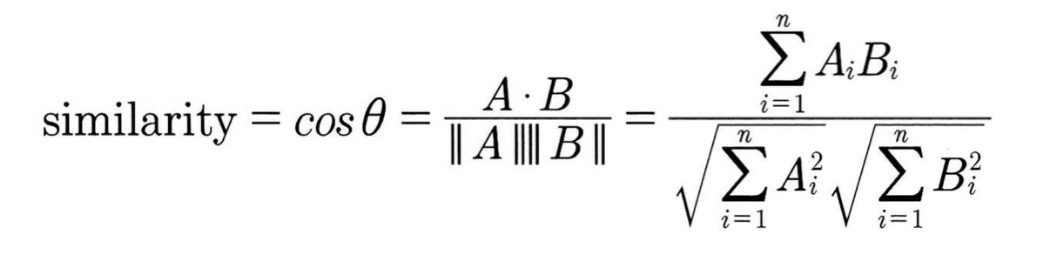



*   코사인 유사도가 문서의 유사도 비교에 가장 많이 사용되는 이유가 있음. 먼저 문서를 피처 벡터화 변환했을 때 차원이 매우 많은 희소 행렬이 되기 쉬운데, 이러한 희소 행렬 기반에서 문서와 문서 벡터 간의 크기에 기반한 유사도 지표(e.g. 유클리드 거리 기반 지표)는 정확도가 떨어지기 쉬움. 또한 문서가 매우 긴 경우 단어의 빈도수도 더 많을 것이기 때문에 이러한 빈도수에만 기반해서는 공정한 비교를 할 수 없음. (e.g. A 문서에서 '머신러닝'이라는 단어가 5번 언급되고 B 문서에서는 3번 언급됐을 때 A 문서가 '머신러닝'과 더 밀접하게 관련된 문서라고 쉽게 판단해서는 안 됨. A 문서가 B 문서보다 10배 이상 크다면 오히려 B 문서가 '머신러닝'과 더 밀접하게 관련된 문서라고 판단할 수 있음.)




In [5]:
# 두 개의 넘파이 배열에 대한 코사인 유사도를 구하는 cos_similarity() 함수

import numpy as np

def cos_similarity(v1, v2):
  dot_product = np.dot(v1, v2)
  l2_norm = (np.sqrt(sum(np.square(v1)))) * (np.sqrt(sum(np.square(v2))))
  similarity = dot_product / l2_norm

  return similarity

In [6]:
# doc_list로 정의된 3개의 간단한 문서의 유사도를 비교하기 위해 문서를 TF-IDF로 벡터화된 행렬로 변환

from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the story ends',
            'if you take the red pill, you stay in Wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [7]:
# 반환된 행렬은 희소 행렬이므로 cos_similarity() 함수의 인자인 array로 만들기 위해 밀집 행렬로 변환한 뒤 다시 각각을 배열로 변환
feature_vect_dense = feature_vect_simple.todense()

## 첫 번째 문장과 두 번째 문장의 피처 벡터 추출
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )

## 첫 번째 문장과 두 번째 문장의 피처 벡터로 두 개 문장의 코사인 유사도 추출
similarity_simple = cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도: 0.402


In [8]:
## 첫 번째 문장과 세 번째 문장의 유사도 측정
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect3)
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

## 두 번째 문장과 세 번째 문장의 유사도 추출
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect2, vect3)
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456




*   사이킷런은 코사인 유사도를 측정하기 위해 **sklearn.metrics.pairwise.cosine_similarity API**를 제공함. **cosine_similarity()** 함수는 두 개의 입력 파라미터를 받음. **첫 번째 파라미터는 비교 기준이 되는 문서의 피처 행렬, 두 번째 파라미터는 비교되는 문서의 피처 행렬임.** cosine_similarity()는 희소 행렬, 밀집 행렬 모두가 가능하며 행렬 또는 배열 모두 가능함. 따라서 앞에서 만든 cos_similarity() 함수와 같이 별도의 변환 작업이 필요 없음.




In [9]:
# 첫 번째 문서와 비교해 바로 자신 문서인 첫번째, 그리고 두 번째, 세 번째 문서의 유사도 측정

from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


첫 번째 유사도 값인 1은 비교 기준인 첫 번째 문서 자신에 대한 유사도 측정임. 두 번째 유사도 값은 첫 번째 문서와 두 번째 문서의 유사도, 세 번째 유사도 값은 첫 번째 문서와 세 번째 문서의 유사도 값임.


*   만일 1이라는 값이 거슬린다면 비교 대상에서 feature_vect[1:]을 이용해 비교 기준 문서를 제외하면 됨.



In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]




*   cosine_similarity()는 쌍으로(pair) 코사인 유사도 값을 제공할 수 있음.



In [11]:
# 모든 개별 문서에 쌍으로 코사인 유사도 값 계ㅅ산

similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


### Opinion Review 데이터 세트를 이용한 문서 유사도 측정


In [12]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from google.colab import drive
drive.mount('/content/drive') # 드라이브에서 불러올 경우

# 필수 NLTK 데이터 다운로드
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

def LemNormalize(text):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in word_tokenize(text)]

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [15]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

file_path = '/content/labeledTrainData.tsv'

try:
    df_raw = pd.read_csv(file_path, sep='\t', encoding='latin1')
    if 'id' in df_raw.columns:
        filenames = df_raw['id'].apply(lambda x: x.split('_')[0]).tolist() # Extract ID part before '_'
    else:
        filenames = [f'doc_{i}' for i in range(len(df_raw))]

    if 'review' in df_raw.columns:
        opinion_text_data = df_raw['review'].astype(str).tolist()
    else:
        raise ValueError("The TSV file does not seem to contain a 'review' column for text data. Please check your file and update the column name in the code.")

    document_df = pd.DataFrame({'filename': filenames, 'opinion_text': opinion_text_data})

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
    document_df = pd.DataFrame({'filename': [], 'opinion_text': []})
    print(f"An error occurred while reading the TSV file: {e}")
    document_df = pd.DataFrame({'filename': [], 'opinion_text': []})

if not document_df.empty:
    tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                                 ngram_range=(1, 2), min_df=0.05, max_df=0.85 )
    feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])
    km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0, n_init='auto')
    km_cluster.fit(feature_vect)
    cluster_label = km_cluster.labels_
    cluster_centers = km_cluster.cluster_centers_
    document_df['cluster_label'] = cluster_label
else:
    print("Document DataFrame is empty, skipping TF-IDF and KMeans steps. Please resolve the data loading issue.")

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


In [16]:
# 호텔을 주제로 군집화된 문서를 이용해 특정 문서와 다른 문서 간의 유사도 측정

from sklearn.metrics.pairwise import cosine_similarity

## 먼저 호텔을 주제로 군집화된 데이터를 먼저 추출하고 이 데이터에 해당하는 TfidfVectorizer로 만들어진 데이터에서 그대로 추출
hotel_indexes = document_df[document_df['cluster_label']==2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index: ', hotel_indexes)
comparison_docname = document_df.loc[hotel_indexes[0], 'filename']    ## 호텔로 군집화된 데이터 중 첫 번째 문서를 추출해 파일명ㅇ ㄹ표시
print('비교 기준 문서명 ', comparison_docname, ' 와 타 문서 유사도')

## document_df에서 추출한 Index 객체를 feature_vect로 입력해 호텔 군집화된 feature_vect를 추출하고, 이를 이용해 호텔로 군집화된 문서 중 첫 번째 문서와 다른 문서 간의 코사인 유사도 측정
similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index:  Index([    0,     8,    11,    13,    15,    16,    17,    18,    19,    21,
       ...
       24967, 24970, 24971, 24973, 24982, 24983, 24984, 24988, 24991, 24995],
      dtype='int64', length=11339)
비교 기준 문서명  5814  와 타 문서 유사도
[[1.         0.51722072 0.57561016 ... 0.56032435 0.63700785 0.68235355]]


가장 유사도가 큰 파일명 및 유사도:  filename          5727
similarity    0.725436
Name: 0, dtype: object


Text(0.5, 1.0, '5814')

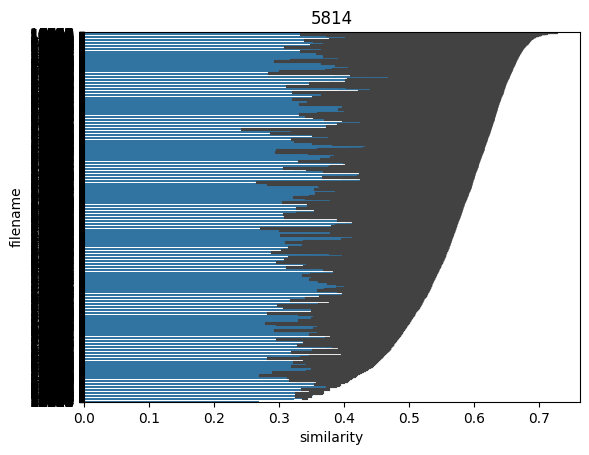

In [17]:
# 단순히 숫자로만 표시해서는 직관적으로 문서가 어느 정도 유사도를 가지는지 이해하기 어려울 수 있으므로 첫 번째 문서와 다른 문서 간에 유사도가 높은 순으로 이를 정렬하고 시각화

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]

hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.loc[hotel_sorted_indexes]['filename'].reset_index(drop=True) # Use .loc for index alignment and reset_index
hotel_1_sim_df['similarity'] = hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도: ', hotel_1_sim_df.iloc[0, :])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)

## 한글 텍스트 처리

### 한글 NLP 처리의 어려움
*   일반적으로 한글 언어 처리는 영어 등의 라틴어 처리보다 어려운데, **그 주된 원인은 띄어쓰기와 다양한 조사 때문**임. 한글은 띄어쓰기를 잘못하면 의미가 왜곡되어 전달될 수 있음. 이와 달리 영어의 경우 띄어쓰기를 잘못했을 때 의미가 왜곡되는 게 아니라 잘못된 또는 없는 단어로 인식되는 게 대부분임. 더구나 영어의 띄어쓰기는 매우 명확함. 또 하나의 중요한 이슈는 바로 조사임. 조사는 주어나 목적어를 위해 추가되며 워낙 경우의 수가 많아 어근 추출(Stemming/Lemmatization) 등의 전처리 시 제거하기가 까다로움.
### KoNLPy 소개
*   KoNLPy는 **파이썬의 대표적인 한글 형태소 패키지**임. 형태소의 사전적인 정의는 '단어로서 의미를 가지는 최소 단위'로 정의할 수 있음. 형태소 분석(Morphologicial Analysis)이란 말뭉치를 이러한 형태소 어근 단위로 쪼개고 각 형태소에 품사 태깅(POS tagging)을 부착하는 작업을 일반적으로 지칭함.
*   KoNLPy 이전에는 팡썬 기반의 형태소 분석 프로그램이 거의 없었으며, 대부분의 형태소 분석은 C/C++과 Java 기반 패키지로 개발되었음. KoNLPy는 기존의 C/C++, Java로 잘 만들어진 한글 형태소 엔진을 파이썬 래퍼(Wrapper) 기반으로 재작성한 패키지임. 기존의 엔진은 그대로 유지한 채 파이썬 기반에서 인터페이스를 제공하기 때문에 검증된 패키지의 안정성을 유지할 수 있음.


In [18]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 29.3 MB/s eta 0:00:00


In [19]:
import pandas as pd

train_df = pd.read_csv('/content/ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [20]:
# 학습 데이터 세트의 0과 1의 Label 값 비율을 살펴봄

train_df['label'].value_counts()

,count
label,
0,75173
1,74827


0과 1의 비율이 어느 한 쪽으로 치우치지 않고 균등한 분포를 나타내고 있음.

In [21]:
import re

train_df = train_df.fillna(' ')    ## train_df의 경우 리뷰 테스트를 가지는 'document' 칼럼에 Null이 일부 존재하므로 이 값은 공백으로 변환함
## 정규 표현식을 이용해 숫자를 공백으로 변경 (* 정규 표현식으로 \d는 숫자를 의미)
train_df['document'] = train_df['document'].apply(lambda x : re.sub(r"\d+", " ", x))

## 테스트 데이터 세트의 경우에도 로딩하고 동일한 데이터 가공 수행
test_df = pd.read_csv('/content/ratings_test.txt', sep='\t', encoding='utf-8')
test_df = test_df.fillna(' ')
test_df['document'] = train_df['document'].apply(lambda x : re.sub(r"\d+", " ", x))

## id 칼럼 삭제 수행
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [22]:
# TF-IDF 방식으로 단어 벡터화

from konlpy.tag import Twitter

## 먼저 각 문장을 한글 형태소 분석을 통해 형태소 단어로 토큰화
twitter = Twitter()
def tw_tokenizer(text):
  ## 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
  tokens_ko = twitter.morphs(text)
  return tokens_ko

/usr/local/lib/python3.13/dist-packages/konlpy/tag/_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


In [ ]:
# 사이킷런의 TfidfVectorizer을 이용해 TF-IDF 피처 모델 생성

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

## Twitter 객체의 morphs() 객체를 이용한 tokenizer를 사용
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# 로지스틱 회귀를 이용해 분류 기반의 감성 분석 수행

lg_clf = LogisticRegrssion(random_state=0, solver='liblinear')

params = {'C': [1, 3.5, 4.5, 5.5, 10]}
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

In [ ]:
# 테스트 세트를 이용해 최종 감성 분석 예측 수행

from sklearn.metrics import accuracy_score

tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)

print('LogisticRegression 정확도: ', accuracy_score(test_df['label'], preds))